In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

data = pd.read_csv("StudentPerformanceFactors1.csv")
data.T

,0,1,2,3,4,5,6,7,8,9,...,6597,6598,6599,6600,6601,6602,6603,6604,6605,6606
Hours_Studied,23,19,24,29,19,19,29,25,17,23,...,16,9,30,12,20,25,23,20,10,15
Attendance,84,64,98,89,92,88,84,78,94,98,...,91,87,94,98,83,69,76,90,86,67
Parental_Involvement,Low,Low,Medium,Low,Medium,Medium,Medium,Low,Medium,Medium,...,High,Low,Medium,Medium,Medium,High,High,Medium,High,Medium
Access_to_Resources,High,Medium,Medium,Medium,Medium,Medium,Low,High,High,Medium,...,Medium,Medium,Low,Low,Low,Medium,Medium,Low,High,Low
Extracurricular_Activities,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,...,Yes,Yes,No,Yes,No,No,No,Yes,Yes,Yes
Sleep_Hours,7,8,7,8,6,8,7,6,6,8,...,6,6,5,4,6,7,8,6,6,9
Previous_Scores,73,59,91,98,65,89,68,50,80,71,...,72,64,52,54,51,76,81,65,91,94
Motivation_Level,Low,Low,Medium,Medium,Medium,Medium,Low,Medium,High,Medium,...,High,Medium,Low,Medium,Low,Medium,Medium,Low,High,Medium
Internet_Access,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,...,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes
Tutoring_Sessions,0,2,2,1,3,3,1,1,0,0,...,0,1,3,2,2,1,3,3,2,0


In [2]:
# PART A – DESCRIPTIVE ANALYTICS------------------------------------------------------------
# Descriptive analytics is used to summarize the dataset.
# In this part, we checked missing and duplicate values,
#-----------------------------------------------------------------------------------


# 1. Check Missing Values
print("Missing Values:\n", data.isnull().sum())

Missing Values:
 Id                             0
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Gender                         0
Exam_Score                     0
dtype: int64


In [5]:
# Fill numeric columns with mean
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].mean())

# Fill categorical columns with mode
cat_cols = data.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

print("Missing values after filling:")
print(data.isnull().sum())

Missing values after filling:
Id                            0
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Gender                        0
Exam_Score                    0
dtype: int64


In [6]:
# 2. Check Duplicate Records
print("\nDuplicate Records:", data.duplicated().sum())

# 3. Summary Statistics
print("\nSummary Statistics:\n", data.describe().T)


Duplicate Records: 0

Summary Statistics:
                     count         mean          std   min     25%     50%  \
Id                 6607.0  3304.000000  1907.420946   1.0  1652.5  3304.0   
Hours_Studied      6607.0    19.975329     5.990594   1.0    16.0    20.0   
Attendance         6607.0    79.977448    11.547475  60.0    70.0    80.0   
Sleep_Hours        6607.0     7.029060     1.468120   4.0     6.0     7.0   
Previous_Scores    6607.0    75.070531    14.399784  50.0    63.0    75.0   
Tutoring_Sessions  6607.0     1.493719     1.230570   0.0     1.0     1.0   
Physical_Activity  6607.0     2.967610     1.031231   0.0     2.0     3.0   
Exam_Score         6607.0    67.190101     4.088990  24.0    65.0    67.0   

                      75%     max  
Id                 4955.5  6607.0  
Hours_Studied        24.0    44.0  
Attendance           90.0   100.0  
Sleep_Hours           8.0    10.0  
Previous_Scores      88.0   100.0  
Tutoring_Sessions     2.0     8.0  
Physical_A

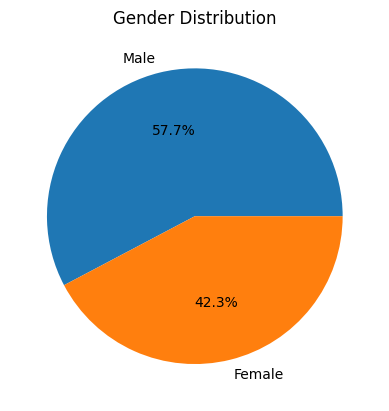

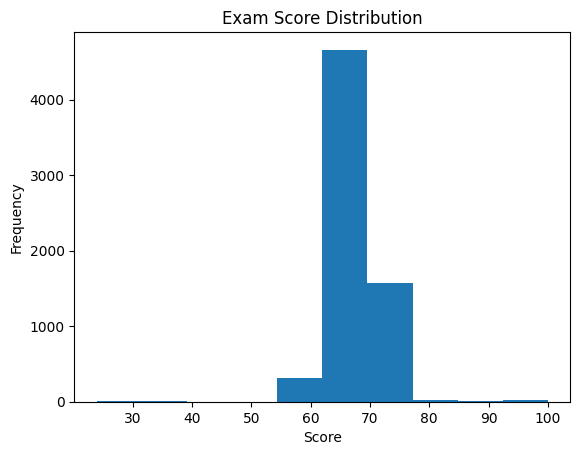

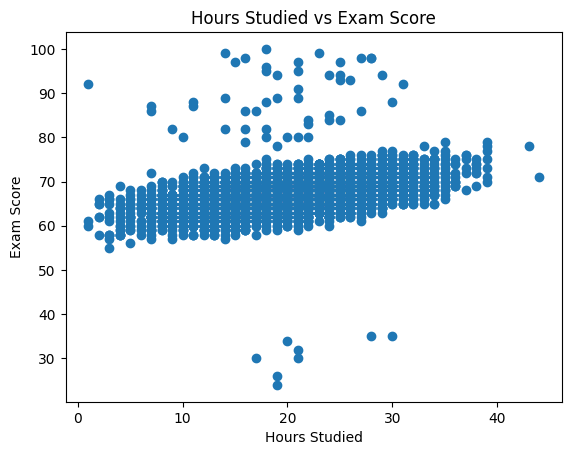

In [7]:
# 4. Gender Distribution (Pie Chart)
gender_counts = data['Gender'].value_counts()
plt.figure()
gender_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

# Exam Score Distribution
plt.figure()
plt.hist(data['Exam_Score'])
plt.title("Exam Score Distribution")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

# Study Hours vs Score
plt.figure()
plt.scatter(data['Hours_Studied'], data['Exam_Score'])
plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()


Average Score by Gender:
Gender
Female    67.201217
Male      67.181961
Name: Exam_Score, dtype: float64

Score by Parental Education:
Parental_Education_Level
College         67.273002
High School     66.875943
Postgraduate    67.861303
Name: Exam_Score, dtype: float64

Correlation Matrix:
                         Id  Hours_Studied  Attendance  Sleep_Hours  \
Id                 1.000000      -0.029716    0.005370     0.006110   
Hours_Studied     -0.029716       1.000000   -0.009908     0.010977   
Attendance         0.005370      -0.009908    1.000000    -0.015918   
Sleep_Hours        0.006110       0.010977   -0.015918     1.000000   
Previous_Scores    0.001909       0.024846   -0.020186    -0.021750   
Tutoring_Sessions -0.004750      -0.014282    0.014324    -0.012216   
Physical_Activity -0.027002       0.004624   -0.022435    -0.000378   
Exam_Score        -0.000525       0.420475    0.552119    -0.014537   

                   Previous_Scores  Tutoring_Sessions  Physical_Act

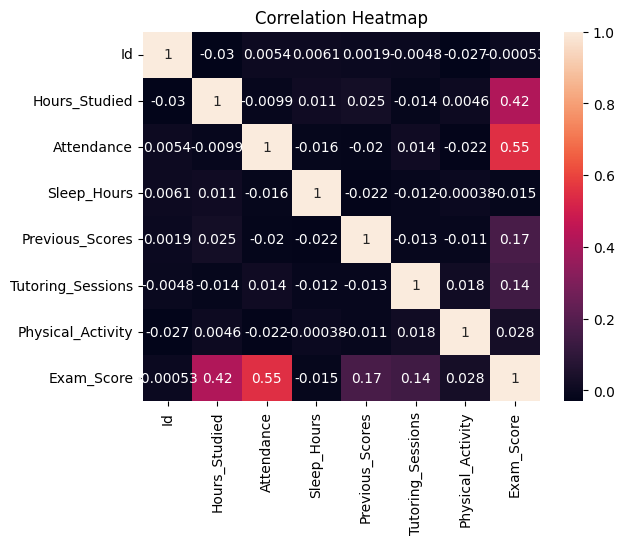


Low Performing Students:
   Id  Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0   1             23          84                  Low                High   
1   2             19          64                  Low              Medium   
4   5             19          92               Medium              Medium   
6   7             29          84               Medium                 Low   
7   8             25          78                  Low                High   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
4                        Yes            6               65           Medium   
6                        Yes            7               68              Low   
7                        Yes            6               50           Medium   

  Internet_Access  Tutoring_Sessions

In [8]:
#PART B – DIAGNOSTIC ANALYTICS

# ============================================================
# GROUP ANALYSIS
# ============================================================

# Gender vs Score
gender_score = data.groupby('Gender')['Exam_Score'].mean()
print("\nAverage Score by Gender:")
print(gender_score)

# Parental Education vs Score
parent_score = data.groupby('Parental_Education_Level')['Exam_Score'].mean()
print("\nScore by Parental Education:")
print(parent_score)


# ============================================================
# CORRELATION ANALYSIS
# ============================================================

correlation = data.corr(numeric_only=True)
print("\nCorrelation Matrix:")
print(correlation)

# Heatmap
plt.figure()
sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap")
plt.show()


# ============================================================
# LOW PERFORMANCE STUDENTS
# ============================================================

low_score = data[data['Exam_Score'] < data['Exam_Score'].mean()]
print("\nLow Performing Students:")
print(low_score.head())

In [11]:

# ============================================================
# PART C – PREDICTIVE ANALYTICS
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Load Dataset
data = pd.read_csv("StudentPerformanceFactors.csv") 

# ============================================================
# 1. Select Important Features (Better Prediction)
# ============================================================

X = data[['Hours_Studied', 'Attendance']]
y = data['Exam_Score']

# ============================================================
# 2. Train-Test Split (80% Train, 20% Test)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================================
# 3. Train Linear Regression Model
# ============================================================

model = LinearRegression()
model.fit(X_train, y_train)

# ============================================================
# 4. Predictions
# ============================================================

y_pred = model.predict(X_test)

# ============================================================
# 5. Model Evaluation
# ============================================================

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R² Score:", r2)
print("MAE:", mae)

# ============================================================
# 6. Predict Exam Score for New Student
# ============================================================

# Example: 8 hours study & 90% attendance
new_student = pd.DataFrame(
    [[8, 90]],
    columns=['Hours_Studied', 'Attendance']
)

future_score = model.predict(new_student)
print("Predicted Exam Score:", round(future_score[0], 2))





R² Score: 0.5269597716689967
MAE: 1.519526485664855
Predicted Exam Score: 65.74


In [11]:

# ============================================================
# PART C – PREDICTIVE ANALYTICS
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Load Dataset
data = pd.read_csv("StudentPerformanceFactors.csv") 

# ============================================================
# 1. Select Important Features (Better Prediction)
# ============================================================

X = data[['Hours_Studied', 'Attendance']]
y = data['Exam_Score']

# ============================================================
# 2. Train-Test Split (80% Train, 20% Test)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================================
# 3. Train Linear Regression Model
# ============================================================

model = LinearRegression()
model.fit(X_train, y_train)

# ============================================================
# 4. Predictions
# ============================================================

y_pred = model.predict(X_test)

# ============================================================
# 5. Model Evaluation
# ============================================================

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R² Score:", r2)
print("MAE:", mae)

# ============================================================
# 6. Predict Exam Score for New Student
# ============================================================

# Example: 8 hours study & 90% attendance
new_student = pd.DataFrame(
    [[8, 90]],
    columns=['Hours_Studied', 'Attendance']
)

future_score = model.predict(new_student)
print("Predicted Exam Score:", round(future_score[0], 2))





R² Score: 0.5269597716689967
MAE: 1.519526485664855
Predicted Exam Score: 65.74


In [13]:
# ============================================================
# PART D – PRESCRIPTIVE ANALYTICS
# ============================================================

# Prescriptive analytics generates recommendations based on
# predicted Exam Score and influencing factors

# ------------------------------------------------------------
# Extract values properly
predicted_score = future_score[0]

study_hours = new_student['Hours_Studied'].values[0]
attendance = new_student['Attendance'].values[0]

print("Predicted Exam Score:", round(predicted_score, 2))

recommendations = []

# ============================================================
# PRIMARY DECISION BASED ON PREDICTION
# ============================================================

if predicted_score < 75:

    if predicted_score < 50:
        recommendations.append(
            "Immediate improvement required. Focus on basic concepts and regular study."
        )

    if attendance < 60:
        recommendations.append(
            "Improve attendance to at least 75% for better understanding."
        )

    if study_hours < 6:
        recommendations.append(
            "Increase study hours to at least 6–8 hours daily."
        )

# DEFAULT RECOMMENDATION (IMPORTANT)
    if len(recommendations) == 0:
        recommendations.append(
            "Maintain consistency and focus on weak subjects."
        )

else:
    recommendations.append(
        "Predicted performance is good. Continue current strategy."
    )

# ============================================================
# DISPLAY RECOMMENDATIONS
# ============================================================

print("\nRecommendations:")
for r in recommendations:
    print("-", r)

Predicted Exam Score: 65.74

Recommendations:
- Maintain consistency and focus on weak subjects.
